# TV sweeps (manual layout): Burgers (noise=0.7, stride_x=5)

Runs multiple training loops (8k steps each) under the baseline dataset settings and varying `lambda_tv`.

For each run it prints:
- `symnet.effective_quadratic_matrix()`
- `symnet.readout.weight`

And generates:
- `hlprs.snapshot_comp(..., snap_no=10)`
- loss curves for data / PDE / TV


In [1]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [24]:
# Baseline dataset settings (matches noise_test.ipynb cell 46)

noise = 0.7
nu = 0.02
stride_t = 10
stride_x = 10
part_num = 1
which_part = 1
seed = SEED

# Training settings
selected_derivs = ('u','u_x','u_xx')

lr = 1e-3
batch_size = 1000
steps = 4000
log_every = 1000

lam_pde = 0.5
lam_reg = 0.0
lam_data = 10.0

# TV sweep
lambda_tv_values = [0.5,1]

# Fixed u-model architecture (change if desired)
U_N_LAYERS = 4
U_HIDDEN = 64
U_ACT = mlps.Sin


In [25]:
# Dataset building

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=seed,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 676
x_unique: 26 t_unique: 26


In [29]:
# TV penalty (smoothed TV in space)

def tv1d_space(u_fn, t, x, eps=1e-6):
    # E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    uxx = torch.autograd.grad(
        ux, x, 
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sqrt(uxx**2 + eps**2).mean()


In [30]:
def run_one(lambda_tv: float):
    # Repro per-run
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    # Initializing u_model and symnet
    u_model = mlps.SimpleMLP(n_layers=U_N_LAYERS, hidden_size=U_HIDDEN, act=U_ACT)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)

    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lambda_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    train = trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

    loss_dat = []
    loss_ps = []
    loss_tv = []

    for i in range(steps):
        t, x, u_noisy, u_clean = hlprs.make_batch(
            batch_size=batch_size,
            t_torch=t_torch,
            x_torch=x_torch,
            y_clean=y_clean_torch,
            y_noisy=y_noisy_torch,
        )

        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean, tv_fn=tv1d_space)
        loss_dat.append(out['loss_data'])
        loss_ps.append(out['loss_pde'])
        loss_tv.append(out['loss_tv'])

        if log_every and i % log_every == 0:
            print(f'[lam_tv={lambda_tv:g}] step {i} data={out["loss_data"]:.6e} pde={out["loss_pde"]:.6e} tv={out["loss_tv"]:.6e}')

    # Print coefficients
    print('[lam_tv=', lambda_tv, '] effective quadratic matrix (symnet):')
    print(symnet.effective_quadratic_matrix(symmetrize=True))
    print('[lam_tv=', lambda_tv, '] readout.weight:')
    print(symnet.readout.weight)

    # Snapshot comparison
    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

    # Loss plots
    plt.figure(figsize=(7,4))
    plt.plot(loss_dat, label='data')
    plt.plot(loss_ps, label='pde')
    plt.plot(loss_tv, label='tv')
    plt.yscale('log')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title(f'Loss curves (lam_tv={lambda_tv:g})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'lambda_tv': lambda_tv,
        'loss_data': loss_dat,
        'loss_pde': loss_ps,
        'loss_tv': loss_tv,
        'train': train,
    }


Running lambda_tv = 0.5
[lam_tv=0.5] step 0 data=1.003694e+00 pde=7.671601e-03 tv=9.007636e-03
[lam_tv=0.5] step 1000 data=5.368120e-01 pde=4.669872e-03 tv=5.330898e-01
[lam_tv=0.5] step 2000 data=5.693208e-01 pde=1.700916e-02 tv=5.205933e-01
[lam_tv=0.5] step 3000 data=5.002778e-01 pde=2.752007e-02 tv=5.228202e-01
[lam_tv= 0.5 ] effective quadratic matrix (symnet):
tensor([[ 0.0042, -0.1345,  0.0457],
        [-0.1345,  0.1173,  0.0087],
        [ 0.0457,  0.0087, -0.0201]])
[lam_tv= 0.5 ] readout.weight:
Parameter containing:
tensor([[-0.0724,  0.1122,  0.1848,  0.3392]], requires_grad=True)
max_abs_diff = 0.422327


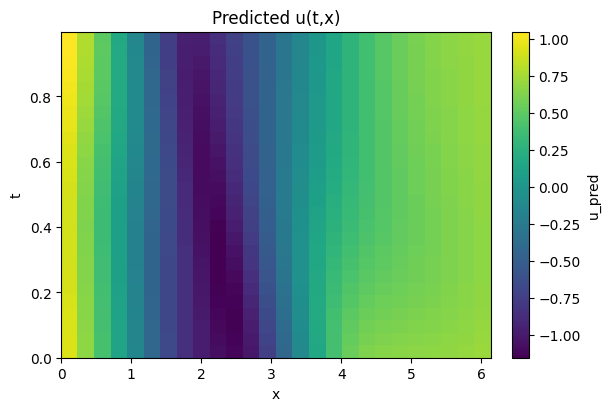

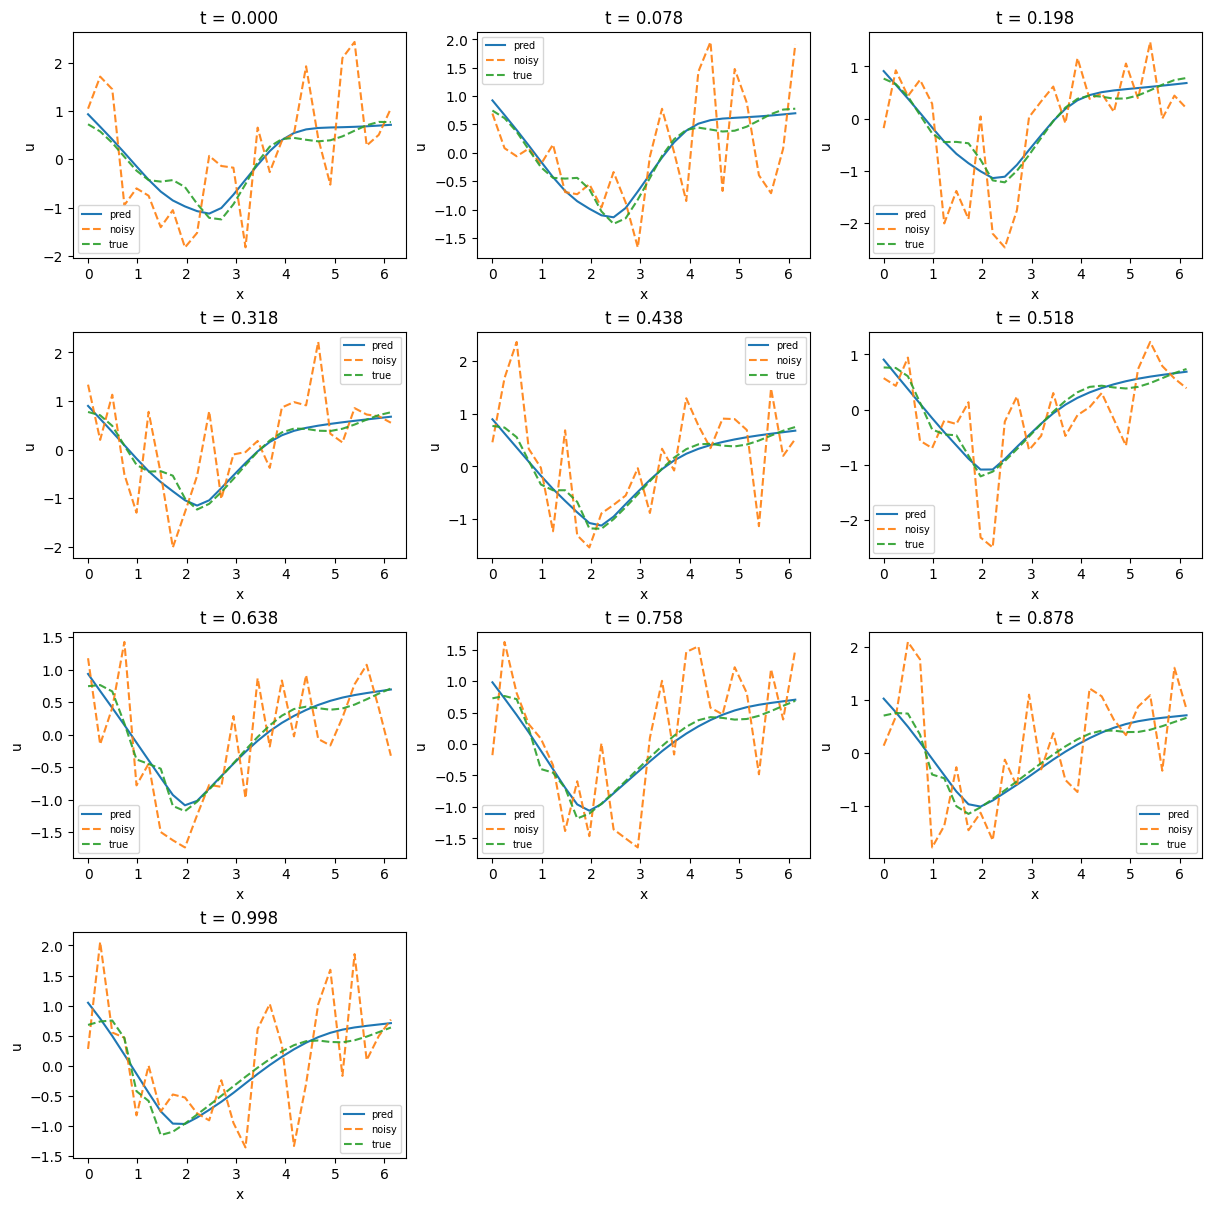

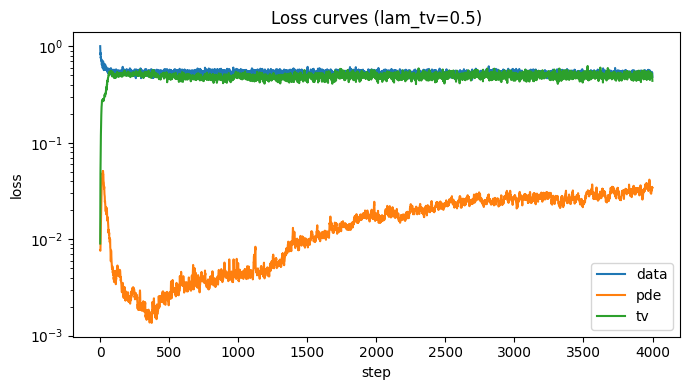

Running lambda_tv = 1
[lam_tv=1] step 0 data=1.003694e+00 pde=7.671601e-03 tv=9.007636e-03
[lam_tv=1] step 1000 data=5.361674e-01 pde=4.536080e-03 tv=4.567983e-01
[lam_tv=1] step 2000 data=5.736094e-01 pde=7.329990e-03 tv=4.185642e-01
[lam_tv=1] step 3000 data=5.048591e-01 pde=1.136803e-02 tv=4.368932e-01
[lam_tv= 1 ] effective quadratic matrix (symnet):
tensor([[ 0.0268, -0.1288,  0.0582],
        [-0.1288,  0.1016,  0.0072],
        [ 0.0582,  0.0072, -0.0327]])
[lam_tv= 1 ] readout.weight:
Parameter containing:
tensor([[-0.0541,  0.0930,  0.2600,  0.3412]], requires_grad=True)
max_abs_diff = 0.458788


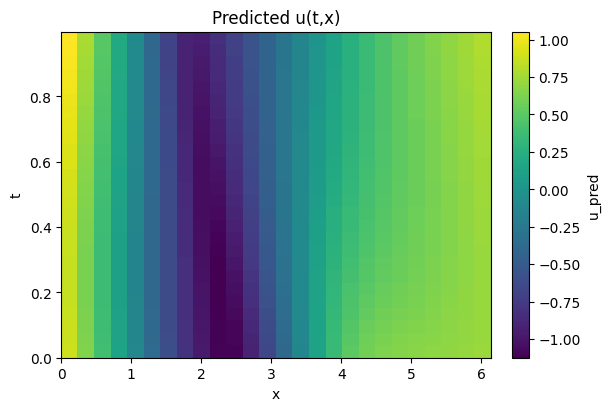

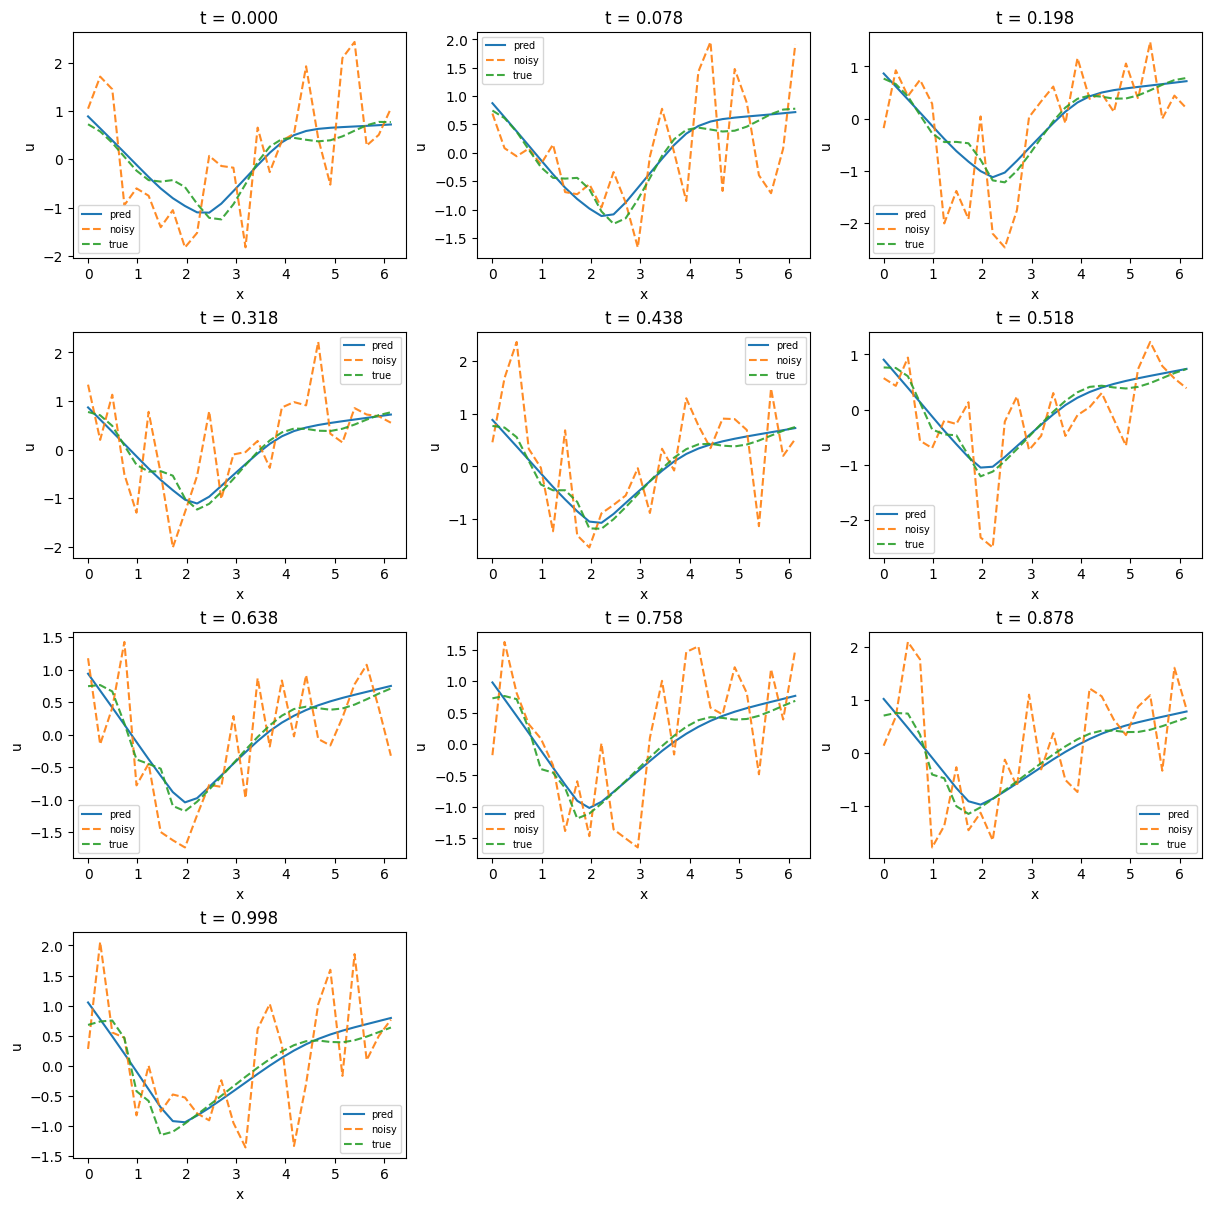

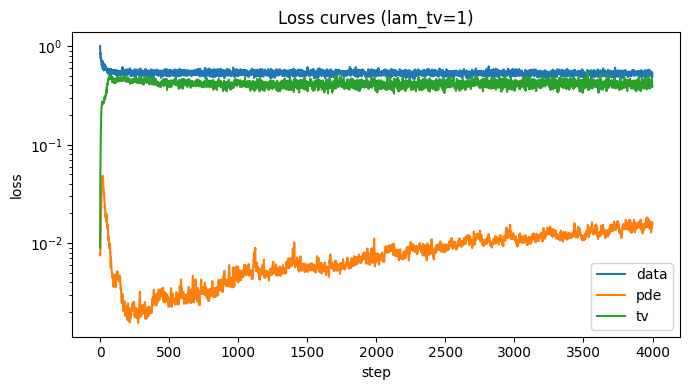

In [31]:
# Run sweeps

results = []
for lam_tv in lambda_tv_values:
    print('==============================')
    print('Running lambda_tv =', lam_tv)
    print('==============================')
    results.append(run_one(lam_tv))


In [18]:
# Compare final losses across lambda_tv

for r in results:
    print(
        f"lam_tv={r['lambda_tv']:>8g} | "
        f"final_data={r['loss_data'][-1]:.6e} "
        f"final_pde={r['loss_pde'][-1]:.6e} "
        f"final_tv={r['loss_tv'][-1]:.6e}"
    )


lam_tv=    0.01 | final_data=4.994399e-01 final_pde=6.730191e-03 final_tv=6.640052e-01
lam_tv=     0.1 | final_data=5.000750e-01 final_pde=6.890255e-03 final_tv=6.342638e-01
lam_tv=     0.5 | final_data=5.030406e-01 final_pde=6.062277e-03 final_tv=5.741525e-01
lam_tv=       1 | final_data=5.078091e-01 final_pde=7.202465e-03 final_tv=5.227994e-01
lam_tv=      10 | final_data=6.928704e-01 final_pde=8.045626e-04 final_tv=1.201067e-01
